# 04 — Hyperparameter Tuning Study

Two configurations × three seeds × four architectures = **24 trials**, 20 epochs
each. This notebook exists to answer one question honestly:

> Is the notebook 02 result a property of the configuration, or just of the seed?

Notebook 02 reported a single point estimate per model from seed 42. With 56 test
images, one image is 1.8% accuracy, so those four numbers could not separate the
architectures. Repeating the *unchanged* configuration across three seeds gives
the baseline an error bar, and only then is it meaningful to ask whether a
different configuration does better.

## What this notebook does NOT do

- It does **not** search a large grid. A wide search on 56 test images selects
  noise.
- It does **not** use the test set to choose anything. See the protocol below.
- It does **not** overwrite notebook 02. Those 60-epoch results stay as the
  baseline of record.

In [1]:
import json
import os
import random
import time
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

warnings = __import__("warnings")
warnings.filterwarnings("ignore")

from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix

from torch.utils.data import Dataset, DataLoader
import torch
import torch.nn as nn
from PIL import Image

torch.backends.cudnn.benchmark = True
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 200)

print("torch", torch.__version__, "| cuda", torch.cuda.is_available())


def banner(msg):
    print("\n" + "=" * 72)
    print("  " + msg)
    print("=" * 72)


def find_project_root(start=None):
    here = Path(start or Path.cwd()).resolve()
    for cand in [here] + list(here.parents):
        if (cand / "notebooks").is_dir() and (cand / "results").is_dir():
            return cand
    return here


PROJECT_ROOT = find_project_root()
RESULTS = PROJECT_ROOT / "results"
for sub in ["tuning", "tuning/curves"]:
    (RESULTS / sub).mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT :", PROJECT_ROOT)

torch 2.10.0+cu128 | cuda True
PROJECT_ROOT : /kaggle/working/BSM-Project


---
## 1. Protocol — why it is shaped this way

The single most important rule:

> **Configuration choice is made on validation accuracy. The test set is read
> once per trial, after the checkpoint has already been chosen, and is never used
> to decide anything.**

Within a trial, the checkpoint is selected by validation accuracy. Only then is
the test split evaluated, once. Those test numbers are *reported* per
configuration, but the declaration of which configuration is preferred is made on
validation and stands regardless of what test says.

Test is evaluated for all 24 trials on purpose. That is not leakage — 24 reported
numbers is a statistic, whereas *choosing* the maximum of 24 test scores is
leakage. The distinction is selection, not evaluation.

Three seeds (42, 43, 44) make the baseline's spread measurable. Configuration A
is the notebook 02 configuration unchanged, so A doubles as the control.

In [2]:
banner("Configuration space")

# Two architecture-fair configurations.
#
# Weight decay and label smoothing are used instead of dropout on purpose.
# torchvision's VGG16 already contains two Dropout(0.5) layers, while the
# ResNets contain none. Adding a dropout knob would therefore *reduce*
# regularisation for VGG16 and *add* it for the ResNets, biasing any comparison
# between architectures. Weight decay and label smoothing apply identically to
# every architecture, so the cross-architecture comparison stays fair.

CONFIGS = {
    "A_baseline": {
        "weight_decay": 0.0,
        "label_smoothing": 0.0,
        "note": "identical to notebook 02 (seed 42 config), used as the control",
    },
    "B_reg": {
        "weight_decay": 1e-4,
        "label_smoothing": 0.1,
        "note": "weight decay + label smoothing",
    },
}

SEEDS = [42, 43, 44]
TRIAL_EPOCHS = 20          # baseline peaks occur in epochs 2-30; 60 is wasted time
BATCH_SIZE = 32
LEARNING_RATE = 1e-4
IMG_SIZE = 224
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

CLASSES = ["Ilmenite", "Rutile", "Zircon", "Garnet", "Monazite", "Sillimanite"]
CLASS_TO_IDX = {c: i for i, c in enumerate(CLASSES)}
NUM_CLASSES = len(CLASSES)

MODEL_SPECS = {
    "VGG16":     {"arch": "vgg16",   "label": "VGG16 (paper model)",
                  "is_dresnet_approximation": False},
    "ResNet18":  {"arch": "resnet18", "label": "ResNet18 (paper model)",
                  "is_dresnet_approximation": False},
    "ResNet34":  {"arch": "resnet34", "label": "ResNet34 (paper model)",
                  "is_dresnet_approximation": False},
    "D_ResNet":  {"arch": "resnet50", "label": "D-ResNet approximation = torchvision ResNet50",
                  "is_dresnet_approximation": True},
}
MODEL_ORDER = ["VGG16", "ResNet18", "ResNet34", "D_ResNet"]

# Colab has 2 vCPUs; more workers on 2 cores is slower, not faster.
NUM_WORKERS = 0 if os.name == "nt" else 2

TRIALS = [(m, c, s) for m in MODEL_ORDER for c in CONFIGS for s in SEEDS]

print(f"  configs : {list(CONFIGS)}")
print(f"  seeds   : {SEEDS}")
print(f"  models  : {MODEL_ORDER}")
print(f"  epochs  : {TRIAL_EPOCHS} per trial")
print(f"  total trials : {len(TRIALS)}")
for c, spec in CONFIGS.items():
    print(f"    {c:<12} wd={spec['weight_decay']:<7} ls={spec['label_smoothing']:<4} {spec['note']}")


  Configuration space
  configs : ['A_baseline', 'B_reg']
  seeds   : [42, 43, 44]
  models  : ['VGG16', 'ResNet18', 'ResNet34', 'D_ResNet']
  epochs  : 20 per trial
  total trials : 24
    A_baseline   wd=0.0     ls=0.0  identical to notebook 02 (seed 42 config), used as the control
    B_reg        wd=0.0001  ls=0.1  weight decay + label smoothing


---
## 2. GPU check

In [3]:
banner("GPU")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if device.type != "cuda":
    print("  NO CUDA. The 24-trial budget assumes a T4; on CPU this is not viable.")
else:
    props = torch.cuda.get_device_properties(0)
    print(f"  device : {props.name}")
    print(f"  memory : {props.total_memory / 1e9:.1f} GB")
    print(f"  cc     : {props.major}.{props.minor}")
    print(f"  dataloader workers : {NUM_WORKERS}")


  GPU
  device : Tesla T4
  memory : 15.6 GB
  cc     : 7.5
  dataloader workers : 2


---
## 3. Data — identical to notebook 02

The split is **not** re-derived. Notebook 04 reads notebook 01's
`final_split_manifest.csv` and re-uses the exact same 3072 / 55 / 56 rows, so
these trials are directly comparable with the notebook 02 baseline. The leakage
re-check is repeated here rather than assumed.

In [4]:
banner("Load manifest and re-check leakage")

MANIFEST = RESULTS / "preprocessing" / "final_split_manifest.csv"
if not MANIFEST.exists():
    raise SystemExit(
        f"{MANIFEST} not found. Run 01_Data_Preprocessing_and_EDA.ipynb "
        "and 02_Model_Experiments.ipynb first."
    )

manifest = pd.read_csv(MANIFEST)
manifest["class_idx"] = manifest["class"].map(CLASS_TO_IDX)

print(f"  manifest rows : {len(manifest)}")
print(manifest.groupby("split").size().reindex(["train", "val", "test"]).to_string())

# The manifest stores absolute paths from whichever machine ran notebook 01.
# Re-root them onto this project so the notebook also works outside Colab.
def repair_path(p):
    p = Path(p)
    if p.exists():
        return p
    s = str(p)
    for marker in ["/data/", "\\data\\"]:
        if marker in s:
            tail = s.split(marker, 1)[1]
            cand = PROJECT_ROOT / "data" / tail
            if cand.exists():
                return cand
    hits = list((PROJECT_ROOT / "data").rglob(p.name)) if (PROJECT_ROOT / "data").is_dir() else []
    return hits[0] if hits else p


manifest["sample_path"] = [str(repair_path(p)) for p in manifest["sample_path"]]

missing = [p for p in manifest["sample_path"] if not Path(p).exists()]
if missing:
    raise SystemExit(
        f"{len(missing)} sample files from the manifest are missing, "
        f"e.g. {missing[:3]}. Re-run notebook 01 in this runtime."
    )
print("  all sample files resolved on disk")

train_df = manifest[manifest["split"] == "train"].reset_index(drop=True)
val_df = manifest[manifest["split"] == "val"].reset_index(drop=True)
test_df = manifest[manifest["split"] == "test"].reset_index(drop=True)

tr_src = set(train_df["source_image_id"])
assert not (tr_src & set(val_df["source_image_id"])), "LEAKAGE train/val"
assert not (tr_src & set(test_df["source_image_id"])), "LEAKAGE train/test"
assert not (val_df["is_augmented"].any() or test_df["is_augmented"].any()), \
    "LEAKAGE augmented samples in val/test"
print("  leakage re-check PASSED")


  Load manifest and re-check leakage
  manifest rows : 3183
split
train    3072
val        55
test       56
  all sample files resolved on disk
  leakage re-check PASSED


In [5]:
import torchvision.transforms as T

# The augmentations are already materialised on disk by notebook 01, so the
# training transform is deterministic on purpose — no second random round.
train_transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE), interpolation=T.InterpolationMode.BILINEAR),
    T.ToTensor(),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])
eval_transform = train_transform


class BSMDataset(Dataset):
    def __init__(self, frame, transform):
        self.paths = frame["sample_path"].tolist()
        self.labels = frame["class_idx"].astype(int).tolist()
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, i):
        with Image.open(self.paths[i]) as im:
            x = self.transform(im.convert("RGB"))
        return x, self.labels[i]


def loader_for(frame, shuffle):
    return DataLoader(BSMDataset(frame, train_transform if shuffle else eval_transform),
                      batch_size=BATCH_SIZE, shuffle=shuffle,
                      num_workers=NUM_WORKERS, pin_memory=True,
                      persistent_workers=NUM_WORKERS > 0)


train_loader = loader_for(train_df, True)
val_loader = loader_for(val_df, False)
test_loader = loader_for(test_df, False)

print(f"  train {len(train_loader.dataset)} | val {len(val_loader.dataset)} "
      f"| test {len(test_loader.dataset)} | steps/epoch {len(train_loader)}")

  train 3072 | val 55 | test 56 | steps/epoch 96


---
## 4. Models, metrics, seeding

In [6]:
banner("Models")

from torchvision import models as tv_models


def build_model(key):
    arch = MODEL_SPECS[key]["arch"]
    if arch == "vgg16":
        net = tv_models.vgg16(weights="IMAGENET1K_V1")
        net.classifier[6] = nn.Linear(net.classifier[6].in_features, NUM_CLASSES)
    else:
        net = getattr(tv_models, arch)(weights="IMAGENET1K_V1")
        net.fc = nn.Linear(net.fc.in_features, NUM_CLASSES)
    return net.to(device)


def param_count(net):
    return sum(p.numel() for p in net.parameters() if p.requires_grad)


for key in MODEL_ORDER:
    net = build_model(key)
    print(f"  {key:<10} arch={MODEL_SPECS[key]['arch']:<9} "
          f"params={param_count(net) / 1e6:6.2f} M")
    del net
print("  model construction PASSED")


  Models
Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:02<00:00, 231MB/s]


  VGG16      arch=vgg16     params=134.29 M
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 199MB/s]


  ResNet18   arch=resnet18  params= 11.18 M
Downloading: "https://download.pytorch.org/models/resnet34-b627a593.pth" to /root/.cache/torch/hub/checkpoints/resnet34-b627a593.pth


100%|██████████| 83.3M/83.3M [00:00<00:00, 200MB/s]


  ResNet34   arch=resnet34  params= 21.29 M
Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 176MB/s]


  D_ResNet   arch=resnet50  params= 23.52 M
  model construction PASSED


In [7]:
banner("Metrics")

# Accuracy, precision, recall (=sensitivity), F1 and specificity.
# Specificity is one-vs-rest TN / (TN + FP); sklearn has no direct equivalent,
# so it is derived from the confusion matrix. Identical to notebook 02.
def compute_all_metrics(y_true, y_pred, classes=CLASSES):
    labels = list(range(len(classes)))
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    acc = accuracy_score(y_true, y_pred)
    prec, rec, f1, sup = precision_recall_fscore_support(
        y_true, y_pred, labels=labels, zero_division=0)

    total = cm.sum()
    specificity = {}
    for i, cls in enumerate(classes):
        tp = int(cm[i, i])
        fn = int(cm[i].sum()) - tp
        fp = int(cm[:, i].sum()) - tp
        tn = total - tp - fn - fp
        specificity[cls] = float(tn / (tn + fp)) if (tn + fp) > 0 else 0.0
    spec_arr = np.array([specificity[c] for c in classes])

    rows = []
    for i, cls in enumerate(classes):
        rows.append({
            "class": cls, "class_idx": i,
            "precision": float(prec[i]), "recall": float(rec[i]),
            "sensitivity": float(rec[i]), "f1_score": float(f1[i]),
            "specificity": float(spec_arr[i]), "support": int(sup[i]),
        })
    rows.append({
        "class": "macro avg", "class_idx": -1,
        "precision": float(prec.mean()), "recall": float(rec.mean()),
        "sensitivity": float(rec.mean()), "f1_score": float(f1.mean()),
        "specificity": float(spec_arr.mean()), "support": int(sup.sum()),
    })
    w = sup / max(sup.sum(), 1)
    rows.append({
        "class": "weighted avg", "class_idx": -2,
        "precision": float((prec * w).sum()), "recall": float((rec * w).sum()),
        "sensitivity": float((rec * w).sum()), "f1_score": float((f1 * w).sum()),
        "specificity": float((spec_arr * w).sum()), "support": int(sup.sum()),
    })
    metrics_df = pd.DataFrame(rows)
    metrics_df.loc[len(metrics_df)] = {
        "class": "accuracy", "class_idx": -3, "precision": float(acc),
        "recall": float(acc), "sensitivity": float(acc), "f1_score": float(acc),
        "specificity": np.nan, "support": int(len(y_true)),
    }
    return float(acc), metrics_df, cm


def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    g = torch.Generator()
    g.manual_seed(seed)
    return g


  Metrics


---
## 5. Trial runner

One trial = one (architecture, configuration, seed). Inside a trial:

1. seed everything
2. train for `TRIAL_EPOCHS`
3. select the checkpoint by **validation accuracy**
4. evaluate the **test** split once on that checkpoint

Trials are appended to `results/tuning/trials.csv` after each completion, so a
reclaimed Colab runtime loses at most one trial. Re-running the notebook skips
trials already recorded.

In [8]:
banner("Trial runner")

TRIALS_CSV = RESULTS / "tuning" / "trials.csv"
CURVES_DIR = RESULTS / "tuning" / "curves"

use_amp = device.type == "cuda"


def evaluate(net, loader):
    # Evaluation always runs in FP32. Under AMP the evaluation forward pass
    # produced NaN for VGG16 in notebook 02.
    net.eval()
    yt, yp, losses = [], [], []
    lossf = nn.CrossEntropyLoss()
    with torch.no_grad():
        for x, y in loader:
            x = x.to(device, non_blocking=True)
            y = y.to(device, non_blocking=True)
            out = net(x)
            losses.append(float(lossf(out, y)))
            yp += out.argmax(1).cpu().tolist()
            yt += y.tolist()
    return yt, yp, float(np.mean(losses))


def run_trial(model_key, config_name, seed):
    cfg = CONFIGS[config_name]
    gen = set_seed(seed)

    train_loader_g = DataLoader(
        BSMDataset(train_df, train_transform), batch_size=BATCH_SIZE, shuffle=True,
        num_workers=NUM_WORKERS, pin_memory=True,
        persistent_workers=NUM_WORKERS > 0, generator=gen)

    net = build_model(model_key)
    lossf = nn.CrossEntropyLoss(label_smoothing=cfg["label_smoothing"])
    opt = torch.optim.Adam(net.parameters(), lr=LEARNING_RATE,
                           weight_decay=cfg["weight_decay"])
    scaler = torch.amp.GradScaler("cuda", enabled=use_amp)

    best_val, best_state, best_ep = -1.0, None, -1
    history = []
    t0 = time.time()

    for epoch in range(1, TRIAL_EPOCHS + 1):
        net.train()
        tot_loss = tot_correct = tot_seen = 0
        te0 = time.time()
        for x, y in train_loader_g:
            x = x.to(device, non_blocking=True)
            y = y.to(device, non_blocking=True)
            opt.zero_grad(set_to_none=True)
            with torch.amp.autocast("cuda", enabled=use_amp):
                out = net(x)
                loss = lossf(out, y)
            scaler.scale(loss).backward()
            scaler.step(opt)
            scaler.update()
            tot_loss += float(loss) * y.size(0)
            tot_correct += int((out.argmax(1) == y).sum())
            tot_seen += int(y.size(0))

        yt, yp, val_loss = evaluate(net, val_loader)
        val_acc = accuracy_score(yt, yp)
        tr_acc = tot_correct / max(tot_seen, 1)
        tr_loss = tot_loss / max(tot_seen, 1)
        et = time.time() - te0

        # A non-finite validation loss is never a valid checkpoint: it means the
        # forward pass blew up even if the argmax happened to look fine.
        if np.isfinite(val_loss) and val_acc > best_val:
            best_val, best_ep = val_acc, epoch
            best_state = {k: v.detach().cpu().clone() for k, v in net.state_dict().items()}

        history.append({"epoch": epoch, "train_loss": tr_loss, "val_loss": val_loss,
                        "train_accuracy": tr_acc, "val_accuracy": val_acc,
                        "epoch_time_seconds": et})
        print(f"      epoch {epoch:>2}/{TRIAL_EPOCHS} | train {tr_acc:.4f} "
              f"| val {val_acc:.4f} | {et:.1f}s")

    if best_state is None:
        raise SystemExit(f"{model_key}/{config_name}/seed{seed}: no valid checkpoint")

    # Checkpoint already chosen on validation. Test is read exactly once, here.
    net.load_state_dict(best_state)
    yt, yp, test_loss = evaluate(net, test_loader)
    test_acc, _, cm = compute_all_metrics(yt, yp)

    hdf = pd.DataFrame(history)
    hdf.to_csv(CURVES_DIR / f"{model_key}__{config_name}__seed{seed}.csv", index=False)

    del net
    if device.type == "cuda":
        torch.cuda.empty_cache()

    return {
        "model": model_key, "config": config_name, "seed": seed,
        "weight_decay": cfg["weight_decay"],
        "label_smoothing": cfg["label_smoothing"],
        "epochs": TRIAL_EPOCHS, "batch_size": BATCH_SIZE,
        "learning_rate": LEARNING_RATE, "train_samples": len(train_df),
        "val_samples": len(val_df), "test_samples": len(test_df),
        "best_epoch": best_ep,
        "best_val_accuracy": best_val,
        "test_accuracy": test_acc, "test_loss": test_loss,
        "final_train_accuracy": float(hdf["train_accuracy"].iloc[-1]),
        "final_train_loss": float(hdf["train_loss"].iloc[-1]),
        "mean_epoch_seconds": float(hdf["epoch_time_seconds"].mean()),
        "wall_seconds": time.time() - t0,
        "completed_at_utc": time.strftime("%Y-%m-%dT%H:%M:%SZ", time.gmtime()),
    }


def load_done():
    if TRIALS_CSV.exists():
        try:
            return pd.read_csv(TRIALS_CSV)
        except Exception:
            return pd.DataFrame()
    return pd.DataFrame()


done = load_done()
done_keys = set()
if len(done):
    done_keys = set(zip(done["model"], done["config"], done["seed"]))
    print(f"  {len(done_keys)} trial(s) already recorded; they will be skipped")
else:
    print("  no previous trials found")


  Trial runner
  no previous trials found


---
## 6. Run all trials

Long-running. Poll the log rather than this cell if it is backgrounded:

```bash
nohup jupyter nbconvert --to notebook --execute notebooks/04_Tuning.ipynb \\
  --inplace --ExecutePreprocessor.timeout=28800 > /content/nb04.log 2>&1 &
```

In [9]:
banner("Run trials")

T0_ALL = time.time()
records = done.to_dict("records") if len(done) else []
n_new = 0

for i, (model_key, config_name, seed) in enumerate(TRIALS, start=1):
    if (model_key, config_name, seed) in done_keys:
        print(f"\n[{i}/{len(TRIALS)}] SKIP {model_key} / {config_name} / seed {seed} (already done)")
        continue

    print(f"\n[{i}/{len(TRIALS)}] {model_key} / {config_name} / seed {seed} "
          f"(wd={CONFIGS[config_name]['weight_decay']}, "
          f"ls={CONFIGS[config_name]['label_smoothing']})")
    rec = run_trial(model_key, config_name, seed)
    print(f"      -> best_ep {rec['best_epoch']}  val {rec['best_val_accuracy']:.4f}  "
          f"test {rec['test_accuracy']:.4f}  ({rec['wall_seconds'] / 60:.1f} min)")
    records.append(rec)
    n_new += 1

    # Incremental write, so a reclaimed runtime costs at most one trial.
    pd.DataFrame(records).to_csv(TRIALS_CSV, index=False)

elapsed = (time.time() - T0_ALL) / 60
print(f"\n  {n_new} new trial(s) in {elapsed:.1f} min")
print(f"  trials recorded : {len(records)} / {len(TRIALS)}")
print(f"  written to      : {TRIALS_CSV}")


  Run trials

[1/24] VGG16 / A_baseline / seed 42 (wd=0.0, ls=0.0)
      epoch  1/20 | train 0.6673 | val 0.6545 | 51.7s
      epoch  2/20 | train 0.9157 | val 0.7273 | 25.4s
      epoch  3/20 | train 0.9733 | val 0.7818 | 26.3s
      epoch  4/20 | train 0.9717 | val 0.7273 | 27.3s
      epoch  5/20 | train 0.9701 | val 0.6727 | 26.6s
      epoch  6/20 | train 0.9707 | val 0.7818 | 26.4s
      epoch  7/20 | train 0.9928 | val 0.7818 | 26.6s
      epoch  8/20 | train 1.0000 | val 0.8364 | 26.5s
      epoch  9/20 | train 1.0000 | val 0.8364 | 26.3s
      epoch 10/20 | train 1.0000 | val 0.8364 | 26.3s
      epoch 11/20 | train 1.0000 | val 0.8545 | 26.3s
      epoch 12/20 | train 1.0000 | val 0.8364 | 26.3s
      epoch 13/20 | train 1.0000 | val 0.8364 | 26.3s
      epoch 14/20 | train 1.0000 | val 0.8364 | 26.3s
      epoch 15/20 | train 1.0000 | val 0.8182 | 26.3s
      epoch 16/20 | train 1.0000 | val 0.8364 | 26.3s
      epoch 17/20 | train 1.0000 | val 0.8364 | 26.3s
      epoch 18

---
## 7. Per-configuration summary

Averaging across seeds is the whole point. The decisive question is whether the
difference between configurations is larger than the spread *within* a
configuration.

In [10]:
banner("Per-configuration summary")

trials = pd.read_csv(TRIALS_CSV)
print(f"  trials: {len(trials)} | expected {len(TRIALS)}")
missing = [t for t in TRIALS if t not in set(zip(trials["model"], trials["config"], trials["seed"]))]
if missing:
    print(f"  WARNING: {len(missing)} trial(s) missing: {missing}")

rows = []
for (model, cfg), g in trials.groupby(["model", "config"]):
    rows.append({
        "model": model, "config": cfg, "n_seeds": len(g),
        "val_mean": g["best_val_accuracy"].mean(),
        "val_std": g["best_val_accuracy"].std(ddof=1) if len(g) > 1 else np.nan,
        "val_min": g["best_val_accuracy"].min(),
        "val_max": g["best_val_accuracy"].max(),
        "test_mean": g["test_accuracy"].mean(),
        "test_std": g["test_accuracy"].std(ddof=1) if len(g) > 1 else np.nan,
        "test_min": g["test_accuracy"].min(),
        "test_max": g["test_accuracy"].max(),
        "best_epoch_mean": g["best_epoch"].mean(),
        "mean_epoch_seconds": g["mean_epoch_seconds"].mean(),
    })

summary = pd.DataFrame(rows).sort_values(["model", "config"])
summary.to_csv(RESULTS / "tuning" / "per_config_summary.csv", index=False)

show = ["model", "config", "n_seeds", "val_mean", "val_std",
        "test_mean", "test_std", "best_epoch_mean"]
print()
print(summary[show].round(4).to_string(index=False))


  Per-configuration summary
  trials: 24 | expected 24

   model     config  n_seeds  val_mean  val_std  test_mean  test_std  best_epoch_mean
D_ResNet A_baseline        3    0.8364   0.0182     0.7143    0.0309           9.3333
D_ResNet      B_reg        3    0.8424   0.0105     0.7857    0.0309           2.6667
ResNet18 A_baseline        3    0.8788   0.0278     0.7679    0.0179           7.6667
ResNet18      B_reg        3    0.8727   0.0182     0.8036    0.0357          10.3333
ResNet34 A_baseline        3    0.8182   0.0315     0.7321    0.0472          11.6667
ResNet34      B_reg        3    0.8485   0.0105     0.7619    0.0273           7.3333
   VGG16 A_baseline        3    0.8485   0.0105     0.7143    0.0179           7.6667
   VGG16      B_reg        3    0.8485   0.0278     0.7321    0.0179           7.3333


In [11]:
banner("Did tuning beat the baseline seed spread?")

# Selection is on VALIDATION. The test columns are printed for transparency but
# play no part in this decision.
lines = []
wins, inconclusive = [], []

for model in MODEL_ORDER:
    sub = summary[summary["model"] == model]
    if len(sub) < 2:
        continue
    a = sub[sub["config"] == "A_baseline"].iloc[0]
    b = sub[sub["config"] == "B_reg"].iloc[0]
    delta = b["val_mean"] - a["val_mean"]
    spread = a["val_std"] if np.isfinite(a["val_std"]) else np.nan
    verdict = "B_reg better on val" if delta > 0 else "A_baseline better on val"
    if np.isfinite(spread) and abs(delta) <= spread:
        verdict += " — but within baseline seed spread, so INCONCLUSIVE"
        inconclusive.append(model)
    else:
        wins.append(model)
    lines.append(
        f"  {model:<10} val A={a['val_mean']:.4f} (sd {a['val_std']:.4f})  "
        f"B={b['val_mean']:.4f}  delta={delta:+.4f}  -> {verdict}"
    )

print("\n".join(lines))
print()
print(f"  decisive in favour of B_reg : {wins if wins else 'none'}")
print(f"  inconclusive               : {inconclusive if inconclusive else 'none'}")
print()
print("  Interpretation: with 56 test images and 3 seeds, a configuration only")
print("  counts as better if its mean validation accuracy exceeds the baseline's")
print("  own seed-to-seed spread. Anything smaller is noise on this dataset.")

verdict_payload = {
    "configs": {k: {kk: vv for kk, vv in v.items()} for k, v in CONFIGS.items()},
    "seeds": SEEDS,
    "trial_epochs": TRIAL_EPOCHS,
    "selection_metric": "best_val_accuracy",
    "decisive_for_B_reg": wins,
    "inconclusive": inconclusive,
    "note": "configuration chosen on validation accuracy; test never used to select",
}
(RESULTS / "tuning" / "tuning_verdict.json").write_text(json.dumps(verdict_payload, indent=2))


  Did tuning beat the baseline seed spread?
  VGG16      val A=0.8485 (sd 0.0105)  B=0.8485  delta=+0.0000  -> A_baseline better on val — but within baseline seed spread, so INCONCLUSIVE
  ResNet18   val A=0.8788 (sd 0.0278)  B=0.8727  delta=-0.0061  -> A_baseline better on val — but within baseline seed spread, so INCONCLUSIVE
  ResNet34   val A=0.8182 (sd 0.0315)  B=0.8485  delta=+0.0303  -> B_reg better on val — but within baseline seed spread, so INCONCLUSIVE
  D_ResNet   val A=0.8364 (sd 0.0182)  B=0.8424  delta=+0.0061  -> B_reg better on val — but within baseline seed spread, so INCONCLUSIVE

  decisive in favour of B_reg : none
  inconclusive               : ['VGG16', 'ResNet18', 'ResNet34', 'D_ResNet']

  Interpretation: with 56 test images and 3 seeds, a configuration only
  counts as better if its mean validation accuracy exceeds the baseline's
  own seed-to-seed spread. Anything smaller is noise on this dataset.


616


  Validation-accuracy curves per trial
  wrote /kaggle/working/BSM-Project/results/tuning/tuning_validation_curves.png


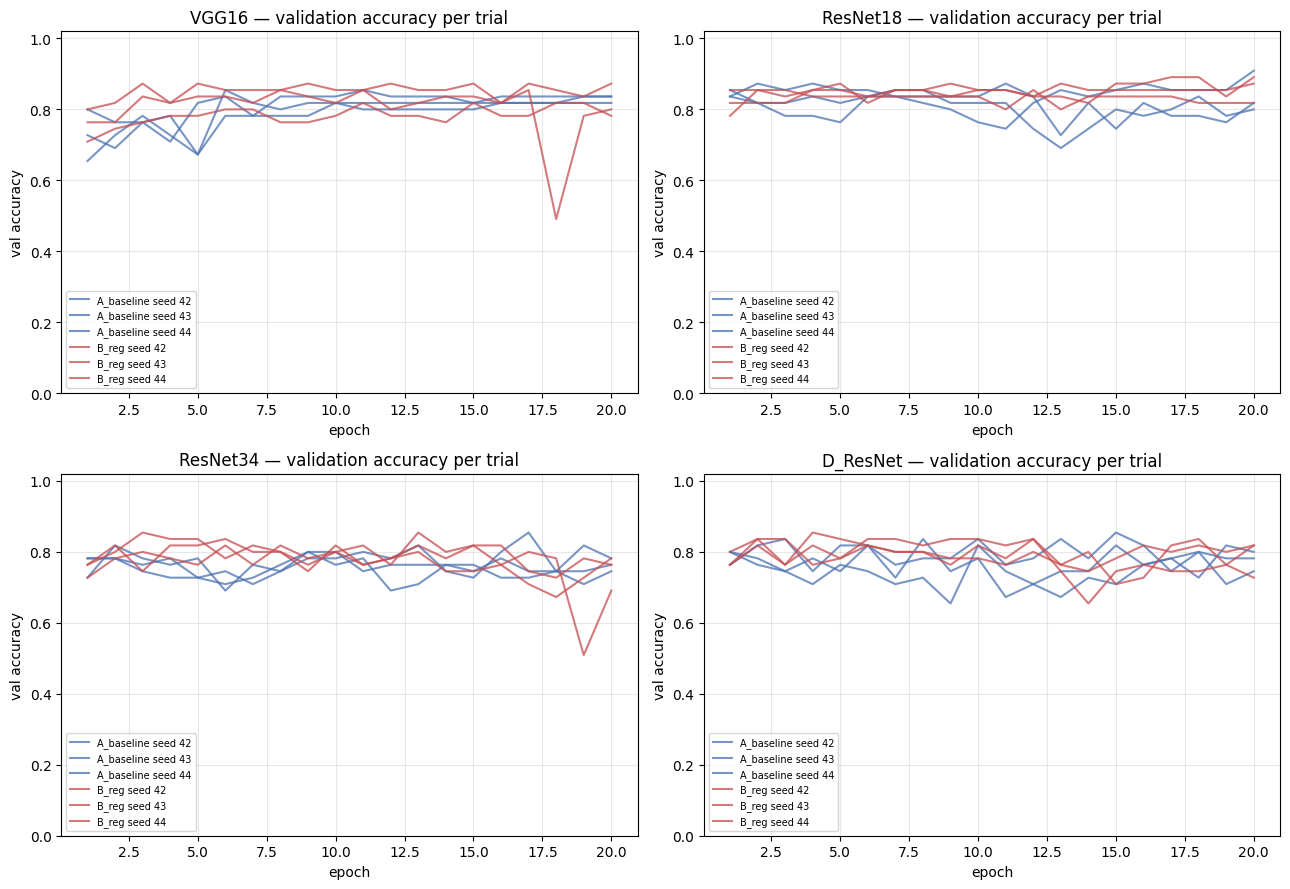

In [12]:
banner("Validation-accuracy curves per trial")

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
for ax, model in zip(axes.ravel(), MODEL_ORDER):
    for cfg, color in [("A_baseline", "#4C72B0"), ("B_reg", "#C44E52")]:
        for seed in SEEDS:
            p = CURVES_DIR / f"{model}__{cfg}__seed{seed}.csv"
            if not p.exists():
                continue
            h = pd.read_csv(p)
            ax.plot(h["epoch"], h["val_accuracy"], color=color, alpha=0.75,
                    label=f"{cfg} seed {seed}")
    ax.set_title(f"{model} — validation accuracy per trial")
    ax.set_xlabel("epoch")
    ax.set_ylabel("val accuracy")
    ax.set_ylim(0, 1.02)
    ax.grid(alpha=0.3)
    ax.legend(fontsize=7)
plt.tight_layout()
out = RESULTS / "tuning" / "tuning_validation_curves.png"
plt.savefig(out, dpi=110)
print(f"  wrote {out}")

---
## 8. What this notebook can and cannot conclude

**Can:** state the seed-to-seed spread of the notebook 02 configuration, and say
whether `B_reg` moves validation accuracy by more than that spread.

**Cannot:** claim an architecture ranking. With 56 test images and three seeds
the intervals still overlap across architectures; `05_Tuning_vs_Baseline.ipynb`
makes that comparison explicit and reports it either way.

The trial budget here is deliberately small (2 configurations, not a grid).
A wider search on 56 test images selects noise rather than finding signal — the
per-trial accuracy quantum is 1/56 = 1.8%, so a "best" configuration found over
dozens of trials would mostly be the luckiest seed.